# Project 4: Customer Churn Prediction

## 1. Project Overview

The goal of this project is to predict customer churn. Churn prediction is a classification task where the model tries to identify customers who are likely to leave the service.

This task is important for business because early detection of customers at risk allows a company to take retention actions, such as offering support, discounts, personalized communication, or improved service conditions.

The target variable is `churn`. A value of `1` means that the customer left the service, while a value of `0` means that the customer stayed.

In this project, several machine learning models will be trained and compared:

- Logistic Regression
- Decision Tree
- Limited-depth Decision Tree
- Random Forest
- Limited-depth Random Forest

The main evaluation metric for this task is recall. Recall is especially important in churn prediction because the business wants to identify as many customers at risk of leaving as possible. A low recall means that many customers who are likely to churn are missed by the model.

## 2. Import Libraries


In [558]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Dataset


In [559]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Data Overview


In [560]:
df.shape

(7043, 21)

In [561]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [562]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [563]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [564]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 5. Exploratory Data Analysis


### Target Distribution

In [565]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [566]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Most customers did not churn. The target classes are imbalanced, so accuracy alone may be misleading. Recall and F1-score will be important metrics for model evaluation.

### Churn Distribution Plot

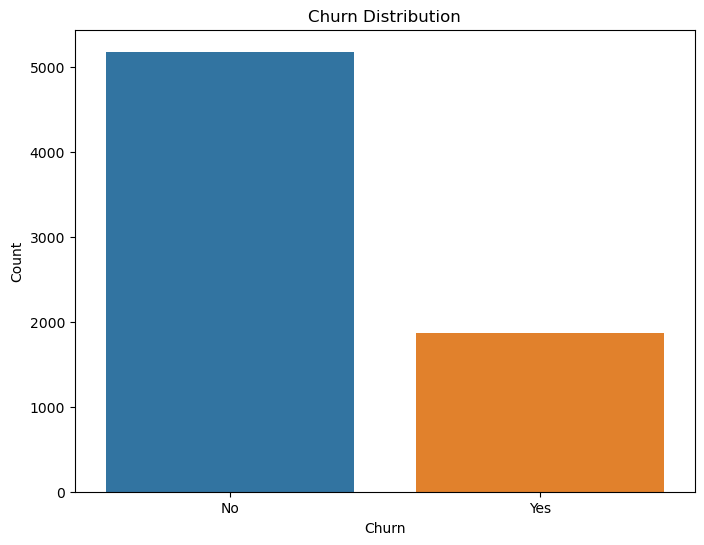

In [567]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x="Churn", hue="Churn", legend=False)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

The chart confirms that non-churned customers are the majority class. This class imbalance should be considered during model evaluation.

### Churn by Contract Type

In [568]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


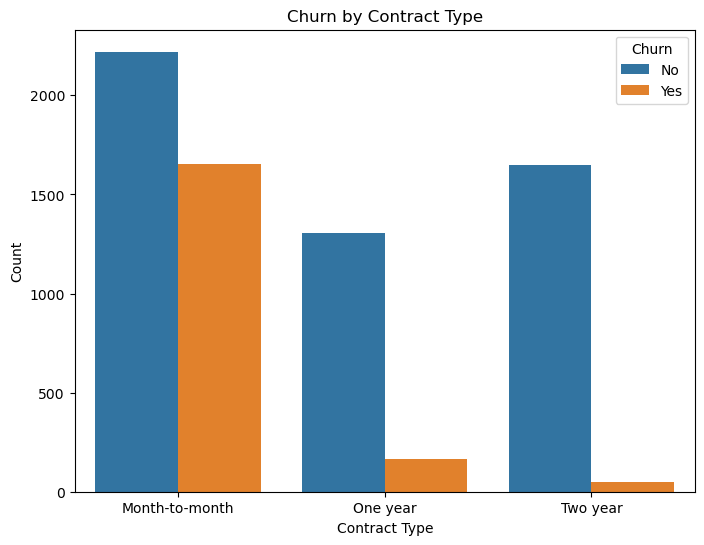

In [569]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

Customers with month-to-month contracts have the highest churn rate. This suggests that shorter contract terms are associated with a higher risk of churn.

### Churn by Tenure

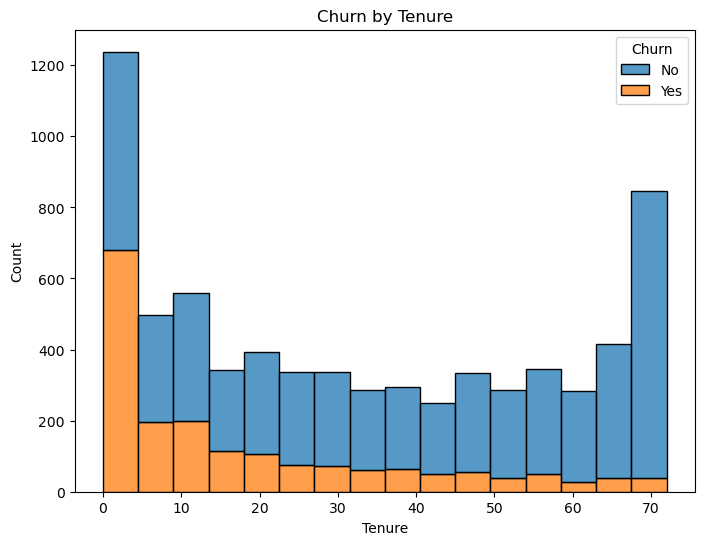

In [570]:
plt.figure(figsize=(8, 6))

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack")

plt.title("Churn by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.show()

Customers with shorter tenure are more likely to churn. This suggests that new customers have a higher churn risk, while long-term customers are more likely to stay.

### Churn by Monthly Charges

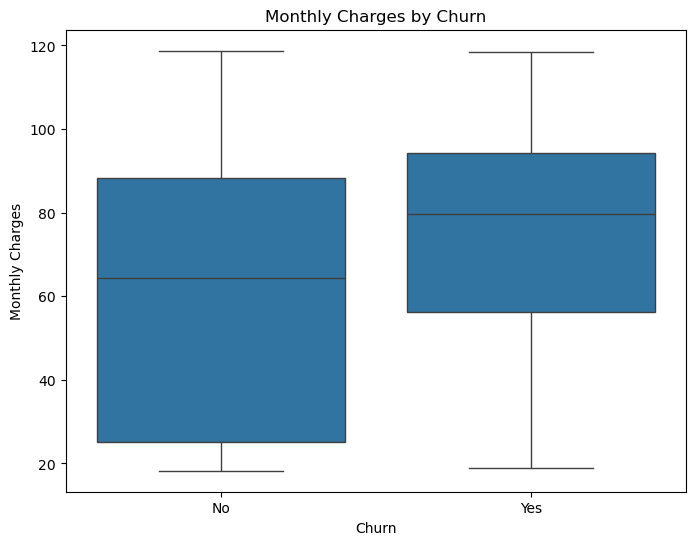

In [571]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Customers who churned tend to have higher monthly charges. This suggests that higher monthly costs may be associated with a higher risk of churn.

### Churn by Payment Method

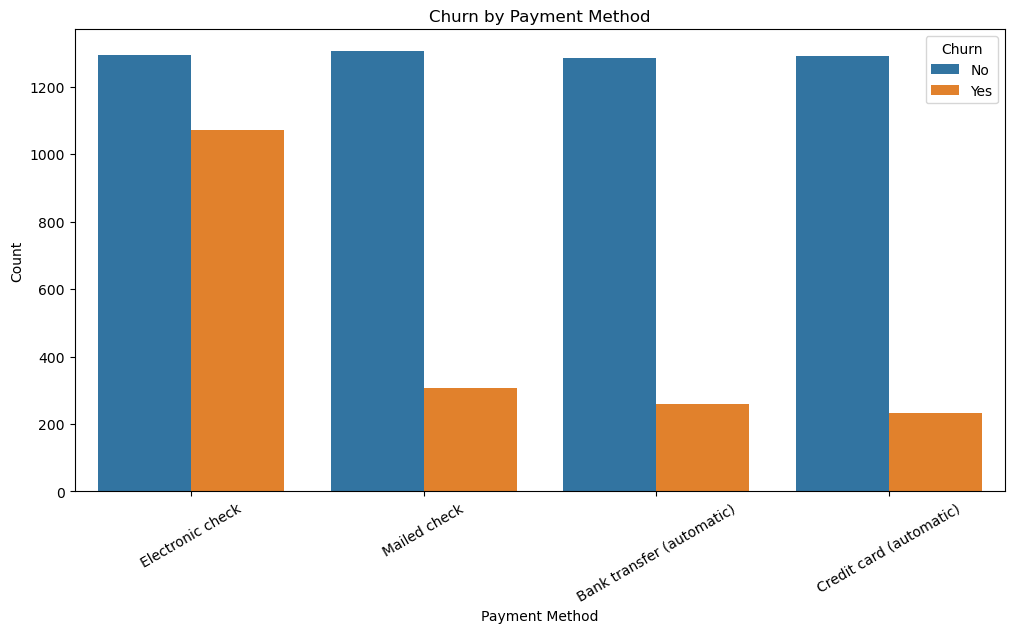

In [572]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [573]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Customers using electronic check have the highest churn rate, with more than 45% of them leaving the service. This suggests that payment method may be associated with churn risk.

### Churn by Internet Service

In [574]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


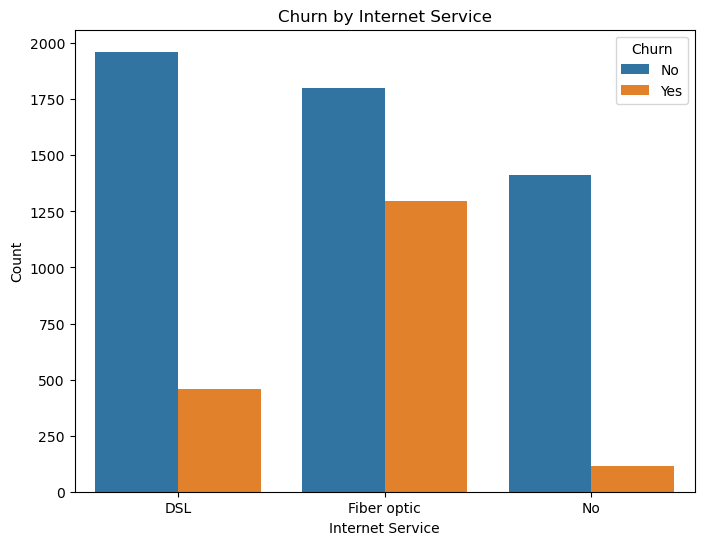

In [575]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.show()

Customers with Fiber optic internet service have the highest churn rate, with more than 41% of them leaving the service. This suggests that Fiber optic customers may have a higher churn risk compared to other internet service groups.

### Churn by Senior Citizen

In [576]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


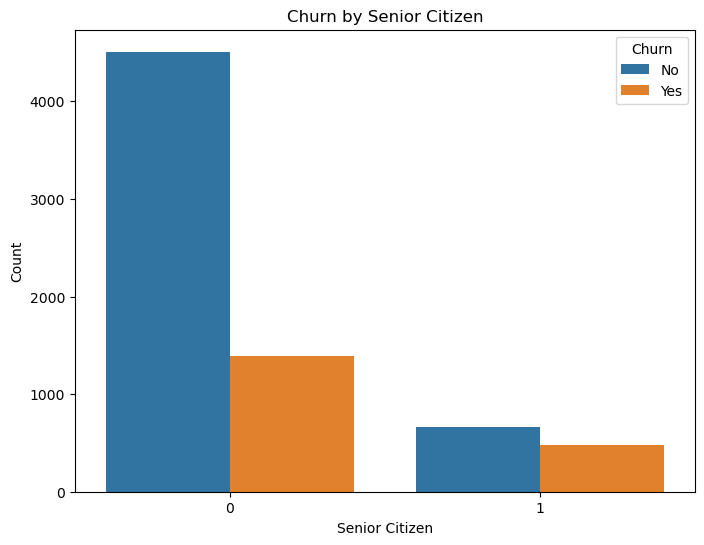

In [577]:
plt.figure(figsize=(8, 6))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")
plt.show()

Customers in the senior citizen group have a churn rate of more than 41%. This suggests that senior citizens may have a higher churn risk compared to non-senior customers.

## 6. Data Cleaning and Feature Preparation


### TotalCharges Conversion

In [578]:
df["TotalCharges"].dtype

dtype('O')

In [579]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [580]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtype

dtype('float64')

In [581]:
df["TotalCharges"].isna().sum()

np.int64(11)

The `TotalCharges` column was stored as an object type. After converting it to numeric format, 11 missing values appeared. These missing values should be handled before model training.

### Missing Values Handling

In [582]:
df.shape

(7043, 21)

In [583]:
df = df.dropna()
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [584]:
df.shape

(7032, 21)

After converting `TotalCharges` to numeric format, 11 missing values were found. Since this is a very small part of the dataset, these rows were removed. The final dataset contains 7032 rows and no missing values.

### Target Encoding

In [585]:
df["Churn"].head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [586]:

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

The `Churn` target variable was encoded into numeric format: `No` was converted to `0`, and `Yes` was converted to `1`.

### Drop ID Column

In [587]:
df = df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [588]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

The `customerID` column was removed because it is a technical identifier and does not provide useful predictive information for the model.

### Split Features and Target

In [589]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape: ", X.shape, "\ny shape: ", y.shape)

X shape:  (7032, 19) 
y shape:  (7032,)


### Categorical Encoding

In [590]:
display(X.shape)

X = pd.get_dummies(X, dtype=int, drop_first=True)

display(X.head())
X.shape

(7032, 19)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


(7032, 30)

In [591]:
X.dtypes.value_counts()

int64      28
float64     2
Name: count, dtype: int64

Categorical features were encoded using one-hot encoding with `drop_first=True`. After encoding, all features are represented in numeric format and can be used for machine learning models.

## 7. Train/Test Split


In [592]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)

Train target distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


The dataset was split into training and test sets using an 80/20 ratio. Stratification was applied to preserve the original churn class distribution in both sets.

## 8. Baseline Model


In [593]:
def model_metrics(test, pred):
    return {
        "accuracy": accuracy_score(test, pred),
        "precision": precision_score(test, pred, zero_division=0),
        "recall": recall_score(test, pred),
        "f1": f1_score(test, pred)
    }

In [594]:
y_pred_baseline = np.zeros(len(y_test), dtype=int)

baseline_metrics = model_metrics(y_test, y_pred_baseline)

The baseline model always predicts the majority class: `0`, meaning that the customer did not churn. This baseline may achieve relatively high accuracy because most customers did not churn, but it has zero recall for the churn class and does not identify any customers at risk.

## 9. Logistic Regression


In [595]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_metrics = model_metrics(y_test, y_pred_lr)
lr_metrics

{'accuracy': 0.8038379530916845,
 'precision': 0.6475903614457831,
 'recall': 0.5748663101604278,
 'f1': 0.6090651558073654}

In [596]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



Logistic Regression achieved an accuracy of about 80%, which means that the model correctly classified most customers in the test set.

However, the class-level metrics show an important difference between the two classes. The model performs better for class 0 customers who did not churn, with high precision and recall. For class 1, which represents customers who churned, the recall is about 57%. This means that the model identifies only a little more than half of the customers who actually left the service.

Since recall for the churn class is especially important in this project, Logistic Regression can be considered a useful and interpretable baseline model, but its ability to detect churned customers is still limited. Tree-based models will be trained next to check whether they can improve recall and overall performance.

## 10. Scaled Logistic Regression

In [ ]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
scaler = StandardScaler()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train_scaled[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test_scaled[numeric_features]
)


lr_scaled = LogisticRegression(max_iter=5000)
lr_scaled.fit(X_train_scaled, y_train)
y_pred_lr_scaled = lr_scaled.predict(X_test_scaled)

lr_scaled_metrics = model_metrics(y_test, y_pred_lr_scaled)

display(lr_metrics)
lr_scaled_metrics

{'accuracy': 0.8038379530916845,
 'precision': 0.6475903614457831,
 'recall': 0.5748663101604278,
 'f1': 0.6090651558073654}

{'accuracy': 0.8045486851457001,
 'precision': 0.6504559270516718,
 'recall': 0.5721925133689839,
 'f1': 0.6088193456614509}

Feature scaling was applied to the numeric features `tenure`, `MonthlyCharges`, and `TotalCharges`.

The scaled Logistic Regression model produced very similar results to the original Logistic Regression model. Accuracy and precision slightly improved, while recall and F1-score slightly decreased.

Since recall and F1-score are important for this churn prediction task, scaling did not improve the final model performance. Therefore, the original Logistic Regression model with adjusted threshold 0.4 remains the selected final model.

## 11. Decision Tree


In [598]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_metrics = model_metrics(y_test, y_pred_dt)
dt_metrics

{'accuracy': 0.7185501066098081,
 'precision': 0.4701086956521739,
 'recall': 0.4625668449197861,
 'f1': 0.46630727762803237}

In [599]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



The Decision Tree model achieved lower performance than Logistic Regression. Its accuracy is about 72%, and the recall for the churn class is about 46%. This means that the model identifies less than half of the customers who actually churned.

The precision for the churn class is also relatively low, which means that many customers predicted as churned did not actually leave the service. Overall, the unrestricted Decision Tree does not perform well on this task and may be overfitting to the training data.

A limited-depth Decision Tree will be trained next to check whether restricting model complexity can improve generalization.

## 12. Limited-depth Decision Tree


In [600]:
dt_limited = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_limited.fit(X_train, y_train)
y_pred_dt_limited = dt_limited.predict(X_test)

dt_limited_metrics = model_metrics(y_test, y_pred_dt_limited)
dt_limited_metrics

{'accuracy': 0.7846481876332623,
 'precision': 0.6563876651982379,
 'recall': 0.3983957219251337,
 'f1': 0.49584026622296173}

In [601]:
print(classification_report(y_test, y_pred_dt_limited))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.66      0.40      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.77      1407



The limited-depth Decision Tree achieved better overall accuracy than the unrestricted Decision Tree. Its precision for the churn class also improved, which means that the model makes fewer false churn predictions.

However, the recall for the churn class decreased to about 40%. This means that the model misses a large share of customers who actually churned. Although limiting tree depth helps control model complexity, this model is too conservative for the churn prediction task, where recall is especially important.

Overall, the limited-depth Decision Tree is more stable than the unrestricted tree, but it is not the best model for identifying customers at risk of churn.

## 13. Random Forest


In [602]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_metrics = model_metrics(y_test, y_pred_rf)
rf_metrics

{'accuracy': 0.7896233120113717,
 'precision': 0.6258064516129033,
 'recall': 0.5187165775401069,
 'f1': 0.5672514619883041}

In [603]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



The Random Forest model achieved an accuracy of about 79%. It performs well for class `0`, customers who did not churn, but its performance for class `1`, customers who churned, is weaker.

The recall for the churn class is about 52%, which means that the model identifies slightly more than half of the customers who actually left the service. This is better than the Decision Tree models, but still lower than Logistic Regression.

Overall, Random Forest provides more stable performance than a single Decision Tree, but in this project it does not outperform Logistic Regression on the most important churn metric: recall.

## 14. Limited-depth Random Forest


In [604]:
rf_limited = RandomForestClassifier(max_depth=5, random_state=42)
rf_limited.fit(X_train, y_train)
y_pred_rf_limited = rf_limited.predict(X_test)

rf_limited_metrics = model_metrics(y_test, y_pred_rf_limited)
rf_limited_metrics

{'accuracy': 0.7945984363894811,
 'precision': 0.683982683982684,
 'recall': 0.42245989304812837,
 'f1': 0.5223140495867769}

In [605]:
print(classification_report(y_test, y_pred_rf_limited))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1033
           1       0.68      0.42      0.52       374

    accuracy                           0.79      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



The limited-depth Random Forest achieved an accuracy of about 79%. Its precision for the churn class is higher than the unrestricted Random Forest, which means that the model makes fewer false churn predictions.

However, the recall for the churn class decreased to about 42%. This means that the model misses a large share of customers who actually churned. For this project, recall is especially important because the goal is to identify as many customers at risk as possible.

Overall, limiting the depth made the Random Forest more conservative, but it reduced its ability to detect churned customers. Therefore, this model is not the best choice for the churn prediction task.

## 15. Model Comparison


In [606]:
models_comparison = pd.DataFrame({
    "model": [
        "baseline",
        "logistic_regression",
        "scaled_logistic_regression",
        "decision_tree",
        "limited_decision_tree",
        "random_forest",
        "limited_random_forest"    
    ],
    "accuracy": [
        baseline_metrics["accuracy"],
        lr_metrics["accuracy"],
        lr_scaled_metrics["accuracy"],
        dt_metrics["accuracy"],
        dt_limited_metrics["accuracy"],
        rf_metrics["accuracy"],
        rf_limited_metrics["accuracy"]
    ],
    "precision": [
        baseline_metrics["precision"],
        lr_metrics["precision"],
        lr_scaled_metrics["precision"],
        dt_metrics["precision"],
        dt_limited_metrics["precision"],
        rf_metrics["precision"],
        rf_limited_metrics["precision"]
    ],
    "recall": [
        baseline_metrics["recall"],
        lr_metrics["recall"],
        lr_scaled_metrics["recall"],
        dt_metrics["recall"],
        dt_limited_metrics["recall"],
        rf_metrics["recall"],
        rf_limited_metrics["recall"]
    ],
    "f1": [
        baseline_metrics["f1"],
        lr_metrics["f1"],
        lr_scaled_metrics["f1"],
        dt_metrics["f1"],
        dt_limited_metrics["f1"],
        rf_metrics["f1"],
        rf_limited_metrics["f1"]
    ]
})

models_comparison.round(3)

,model,accuracy,precision,recall,f1
0,baseline,0.734,0.000,0.000,0.000
1,logistic_regression,0.804,0.648,0.575,0.609
2,scaled_logistic_regression,0.805,0.650,0.572,0.609
3,decision_tree,0.719,0.470,0.463,0.466
4,limited_decision_tree,0.785,0.656,0.398,0.496
5,random_forest,0.790,0.626,0.519,0.567
6,limited_random_forest,0.795,0.684,0.422,0.522


Logistic Regression and Scaled Logistic Regression showed the strongest overall performance among the trained models.

Scaled Logistic Regression achieved slightly higher accuracy and precision, but its recall and F1-score were slightly lower compared with the original Logistic Regression model. Since recall is especially important for churn prediction, the original Logistic Regression model remained the better candidate before threshold tuning.

The limited-depth Random Forest achieved the highest precision, which means it made fewer false churn predictions. However, its recall was much lower, so it missed more customers who actually churned.

The unrestricted Decision Tree showed the weakest overall performance. This suggests that a single decision tree may not generalize well on this dataset.

Overall, the original Logistic Regression model was selected as the best candidate before threshold tuning because it provided the strongest churn detection performance while remaining easy to interpret.

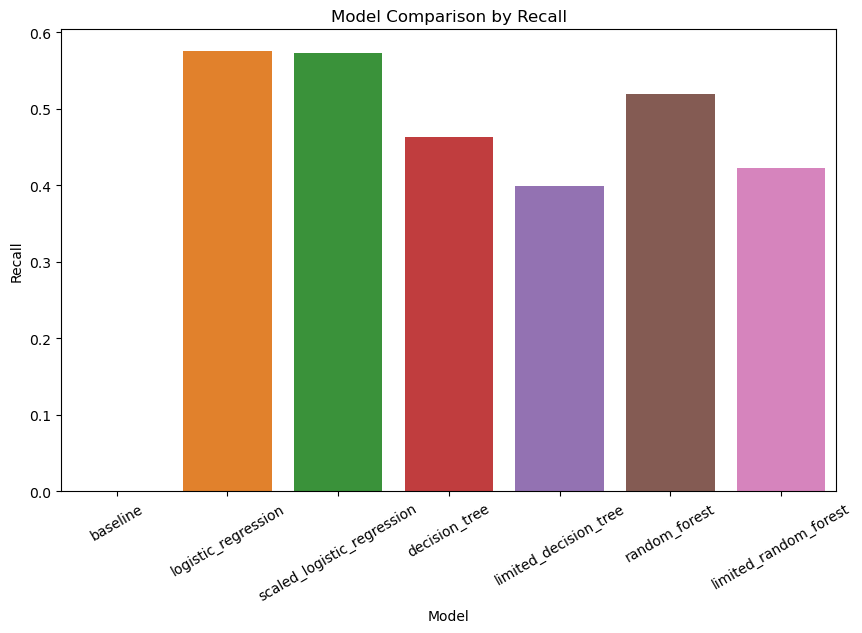

In [607]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=models_comparison,
    x="model",
    y="recall",
    hue="model",
    legend=False
)

plt.title("Model Comparison by Recall")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=30)
plt.show()

Logistic Regression achieved the highest recall among the trained models. Since recall is the key metric for this churn prediction task, Logistic Regression is selected as the best model at this stage.

Random Forest showed the second-best recall, while the limited-depth models were more conservative and missed more churned customers.

## 16. Threshold Tuning

In [608]:
y_proba_lr = lr.predict_proba(X_test)[:, 1]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    pred = (y_proba_lr >= t).astype(int)
    metrics = model_metrics(y_test, pred)
    threshold_results.append({
        "threshold": t,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"]
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,accuracy,precision,recall,f1
0,0.3,0.743426,0.511754,0.756684,0.610572
1,0.4,0.782516,0.576577,0.684492,0.625917
2,0.5,0.803838,0.647590,0.574866,0.609065
3,0.6,0.788913,0.680751,0.387701,0.494037
4,0.7,0.764748,0.759036,0.168449,0.275711


The threshold comparison shows a clear trade-off between recall and precision.

Lower thresholds increase recall, meaning the model identifies more customers who actually churned. However, this also decreases precision, meaning the model produces more false positive churn predictions.

Threshold 0.3 achieved the highest recall of 0.757, which may be useful if the business wants to identify as many at-risk customers as possible.

However, threshold 0.4 achieved the best F1-score of 0.626 and provides a stronger balance between recall and precision. Compared with the default threshold 0.5, threshold 0.4 increased recall from 0.575 to 0.684 while also improving F1-score.

For this project, threshold 0.4 is selected as the preferred threshold because it improves churn detection while keeping a reasonable balance between precision and recall.

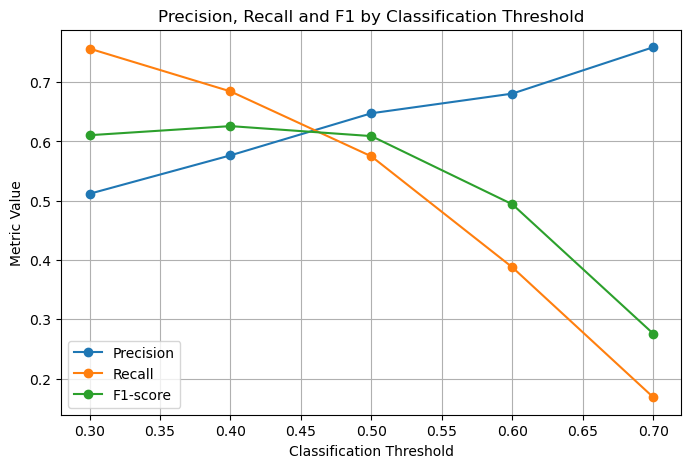

In [609]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    marker="o",
    label="F1-score"
)

plt.title("Precision, Recall and F1 by Classification Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)
plt.show()

The chart shows the trade-off between precision and recall.

As the classification threshold increases, precision improves, but recall decreases. Lower thresholds allow the model to identify more churned customers, but they also increase the number of false positive predictions.

Threshold 0.4 provides the best F1-score and a reasonable balance between recall and precision. For this churn prediction task, threshold 0.4 is selected as the preferred classification threshold.

## 17. Feature Importance


For Logistic Regression, coefficients show how each feature is associated with the probability of churn. Positive coefficients increase the predicted probability of churn, while negative coefficients decrease it.

In [610]:
lr_coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_[0]
})

top_positive_coefficients = lr_coefficients.sort_values(
    "coefficient", ascending=False
).head(5).round(3)

top_positive_coefficients

,feature,coefficient
10,InternetService_Fiber optic,1.238
21,StreamingTV_Yes,0.421
23,StreamingMovies_Yes,0.393
9,MultipleLines_Yes,0.389
28,PaymentMethod_Electronic check,0.384


In [611]:
top_negative_coefficients = lr_coefficients.sort_values(
    "coefficient", ascending=True
).head(5).round(3)

top_negative_coefficients

,feature,coefficient
25,Contract_Two year,-1.350
24,Contract_One year,-0.738
13,OnlineSecurity_Yes,-0.349
19,TechSupport_Yes,-0.308
6,Dependents_Yes,-0.231


The Logistic Regression coefficients show which features are associated with higher or lower churn probability.

The strongest positive coefficient is `InternetService_Fiber optic`, which suggests that customers with fiber optic internet service are more likely to churn. Other positive coefficients include streaming services, multiple lines, and electronic check payment method. These features may be associated with higher churn risk.

The strongest negative coefficients are related to contract type. Customers with one-year and especially two-year contracts are less likely to churn compared to customers with month-to-month contracts. Features such as online security and tech support are also associated with lower churn probability.

These findings are consistent with the exploratory data analysis, where month-to-month contracts, fiber optic internet service, and electronic check payment method were linked to higher churn rates.

## 18. Final Conclusions

This project focused on predicting customer churn using machine learning models.

Several classification models were trained and compared, including Logistic Regression, Scaled Logistic Regression, Decision Tree, limited-depth Decision Tree, Random Forest, and limited-depth Random Forest.

Feature scaling was also tested for Logistic Regression. It slightly improved accuracy and precision, but slightly decreased recall and F1-score. Since recall is especially important in churn prediction, the original Logistic Regression model remained the better candidate for threshold tuning.

Logistic Regression showed the best overall performance among the initial models. Since recall is especially important in churn prediction, threshold tuning was applied to improve the model's ability to identify churned customers.

The default threshold of 0.5 achieved a recall of 0.575 and an F1-score of 0.609. After lowering the classification threshold to 0.4, recall increased to 0.684 and F1-score improved to 0.626.

For this project, Logistic Regression with threshold 0.4 was selected as the final model because it provides a better balance between identifying customers at risk of churn and maintaining reasonable precision.

The project also showed that churn is associated with contract type, internet service type, payment method, and additional services. Customers with month-to-month contracts, fiber optic internet service, and electronic check payment method were more likely to churn, while customers with longer contracts, online security, and tech support were less likely to churn.